In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## LOAD DATASET

In [3]:
data=pd.read_csv('/content/Disease_symptom_and_patient_profile_dataset.csv')
data

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
...,...,...,...,...,...,...,...,...,...,...
344,Stroke,Yes,No,Yes,No,80,Female,High,High,Positive
345,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
346,Stroke,Yes,No,Yes,No,85,Male,High,High,Positive
347,Stroke,Yes,No,Yes,No,90,Female,High,High,Positive


## DATA PREPROCESSING

In [4]:
data.head()

,Disease,Fever,Cough,Fatigue,Difficulty Breathing,Age,Gender,Blood Pressure,Cholesterol Level,Outcome Variable
0,Influenza,Yes,No,Yes,Yes,19,Female,Low,Normal,Positive
1,Common Cold,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
2,Eczema,No,Yes,Yes,No,25,Female,Normal,Normal,Negative
3,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive
4,Asthma,Yes,Yes,No,Yes,25,Male,Normal,Normal,Positive


In [5]:
data.columns

Index(['Disease', 'Fever', 'Cough', 'Fatigue', 'Difficulty Breathing', 'Age',
       'Gender', 'Blood Pressure', 'Cholesterol Level', 'Outcome Variable'],
      dtype='object')

In [6]:
data.index

RangeIndex(start=0, stop=349, step=1)

In [7]:
data.describe()

,Age
count,349.000000
mean,46.323782
std,13.085090
min,19.000000
25%,35.000000
50%,45.000000
75%,55.000000
max,90.000000


In [8]:
data.isnull().sum()

,0
Disease,0
Fever,0
Cough,0
Fatigue,0
Difficulty Breathing,0
Age,0
Gender,0
Blood Pressure,0
Cholesterol Level,0
Outcome Variable,0


In [9]:
#remove duplicates
data.drop_duplicates(inplace=True)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 347
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Disease               300 non-null    object
 1   Fever                 300 non-null    object
 2   Cough                 300 non-null    object
 3   Fatigue               300 non-null    object
 4   Difficulty Breathing  300 non-null    object
 5   Age                   300 non-null    int64 
 6   Gender                300 non-null    object
 7   Blood Pressure        300 non-null    object
 8   Cholesterol Level     300 non-null    object
 9   Outcome Variable      300 non-null    object
dtypes: int64(1), object(9)
memory usage: 25.8+ KB


## HANDLE MISSING VALUES

In [11]:
# Numerical columns
num_cols = data.select_dtypes(include=np.number).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

# Categorical columns
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])


In [12]:
print("\nMissing Values After Cleaning:\n", data.isnull().sum())


Missing Values After Cleaning:
 Disease                 0
Fever                   0
Cough                   0
Fatigue                 0
Difficulty Breathing    0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Outcome Variable        0
dtype: int64


In [13]:
# Normalize Symptom Names
symptom_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']

for col in symptom_cols:
    if col in data.columns:
        data[col] = data[col].astype(str).str.lower().str.strip()

In [14]:
data[col]

,Difficulty Breathing
0,yes
1,no
2,no
3,yes
5,no
...,...
341,no
342,no
343,no
345,no


# Exploratry data analysis

### Distribution of symptoms

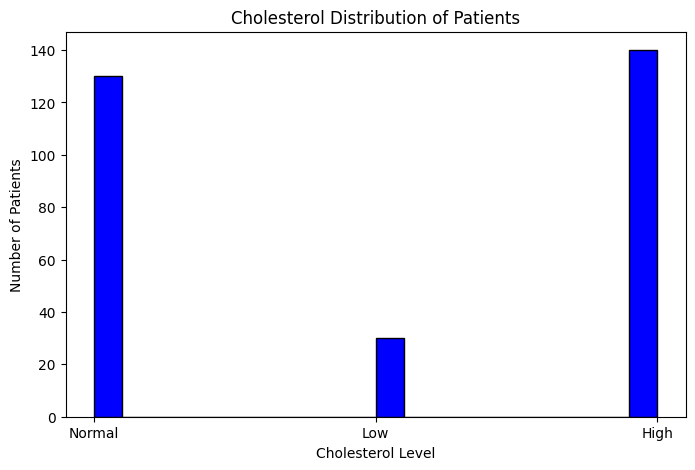

In [15]:
plt.figure(figsize=(8,5))
plt.hist(x=data['Cholesterol Level'], bins=20, color='blue', edgecolor='black')
plt.title('Cholesterol Distribution of Patients')
plt.xlabel('Cholesterol Level')
plt.ylabel('Number of Patients')
plt.show()

### Distribution of Symptoms

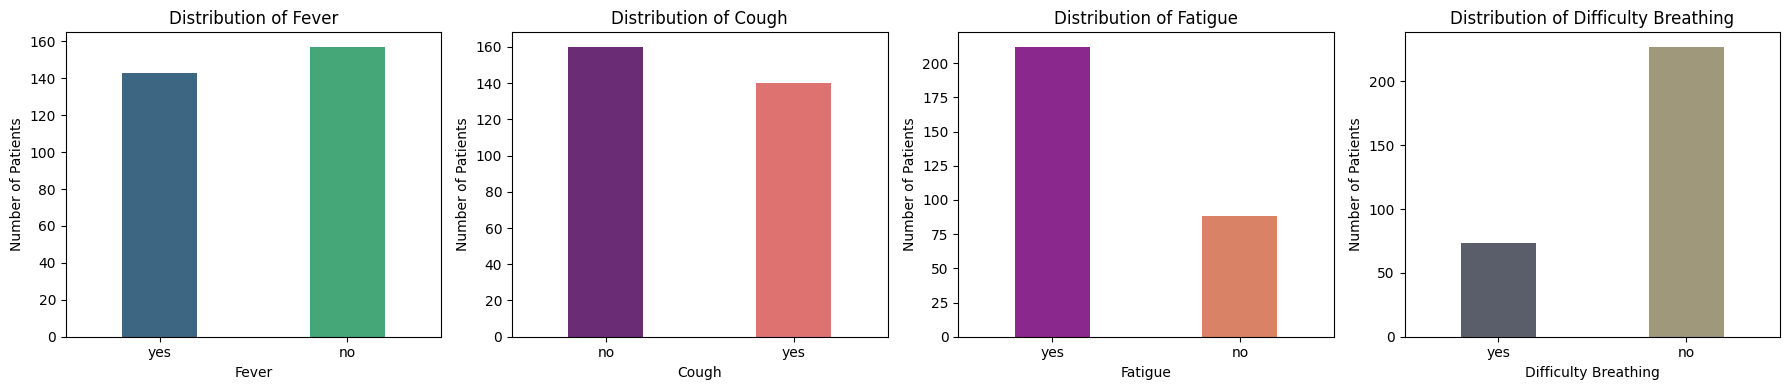

In [16]:

symptom_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']
palettes = ['viridis', 'magma', 'plasma', 'cividis']

# Create a figure with subplots arranged in a 1x4 grid
fig, axes = plt.subplots(1, len(symptom_cols), figsize=(18, 4)) # Adjust figsize for 4 plots in one row

for i, symptom in enumerate(symptom_cols):
    sns.countplot(data=data, x=symptom, palette=palettes[i % len(palettes)], ax=axes[i])
    axes[i].set_title(f'Distribution of {symptom}')
    axes[i].set_xlabel(symptom)
    axes[i].set_ylabel('Number of Patients')

    # Adjust bar width
    for bar in axes[i].patches:
        x = bar.get_x()
        width = bar.get_width()
        new_width = 0.4 # You can adjust this value for desired thinness
        bar.set_x(x + (width - new_width) / 2)
        bar.set_width(new_width)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

## Patient deemographics

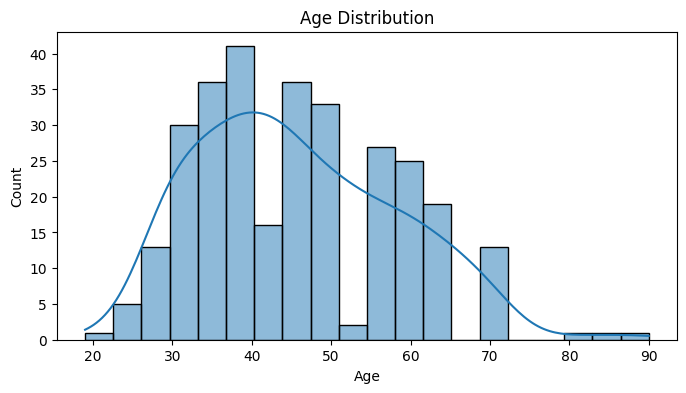

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x='Age', bins=20, kde=True)
plt.title('Age Distribution')
plt.show()



## correlation analysis

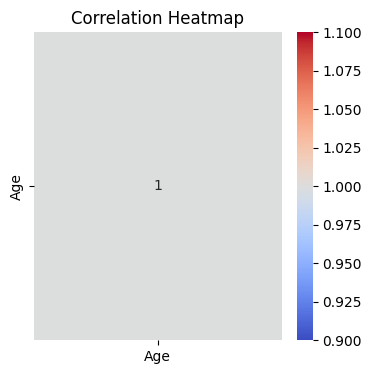

In [18]:

numeric_df = data.select_dtypes(include=[np.number])
plt.figure(figsize=(4, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Predictive Modeling

In [19]:
X = data.drop('Outcome Variable', axis=1)
y = data['Outcome Variable']

In [20]:
X = pd.get_dummies(X, drop_first=True)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [22]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [23]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7333333333333333


In [24]:
from sklearn.metrics import classification_report
print("\n RandomForestClassifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Classification Report:\n", classification_report(y_test, y_pred))


 RandomForestClassifier Results:
Accuracy: 0.7333333333333333
Classification Report:
               precision    recall  f1-score   support

    Negative       0.74      0.63      0.68        27
    Positive       0.73      0.82      0.77        33

    accuracy                           0.73        60
   macro avg       0.73      0.72      0.73        60
weighted avg       0.73      0.73      0.73        60



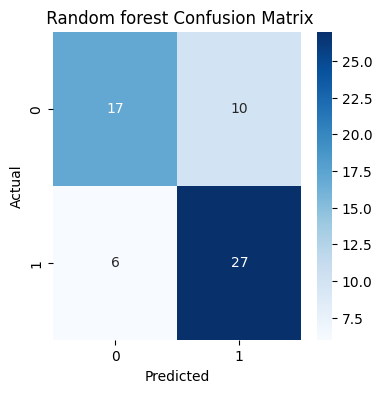

In [25]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title(' Random forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()